# Exploración de Riesgos — PISST
**Objetivo:** Explorar peligros, evaluaciones y medidas de control para validar la lógica de `analizar_riesgos()`.

Este notebook es de solo lectura — nunca escribe en la BD.

## 1. Configuración e imports

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

sys.path.insert(0, os.path.abspath('..'))
load_dotenv('../.env')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('Pandas:', pd.__version__, '| NumPy:', np.__version__)

Pandas: 3.0.3 | NumPy: 2.4.6


## 2. Conexión a la BD

In [2]:
DATABASE_URL = os.getenv("DATABASE_URL")

# Filtrar por empresa — cambiar este UUID según la empresa a analizar
EMPRESA_ID = os.getenv("EMPRESA_ID", None)  # None = leer todas (solo para desarrollo)

if EMPRESA_ID:
    print("Filtrando por empresa:", EMPRESA_ID)
else:
    print("[ADVERTENCIA] Sin filtro de empresa — se muestran datos de TODOS los clientes")

engine = create_engine(DATABASE_URL)

with engine.connect() as conn:
    result = conn.execute(text("SELECT COUNT(*) FROM peligros"))
    print(f"Total peligros en BD: {result.scalar()}")


Peligros: 3 | Evaluaciones: 9 | Controles: 3


## 3. Carga de datos (Ingesta)

In [3]:
filtro = "WHERE p.empresa_id = :empresa_id" if EMPRESA_ID else ""
params = {"empresa_id": EMPRESA_ID} if EMPRESA_ID else {}

# Peligros con su última evaluación de riesgo (no residual)
query_peligros = f"""
SELECT
    p.id             AS peligro_id,
    p.tipo           AS tipo_peligro,
    p.activo,
    p.empresa_id,
    er.nivel_riesgo,
    er.es_residual
FROM peligros p
LEFT JOIN evaluaciones_riesgo er ON er.peligro_id = p.id AND er.es_residual = FALSE
{filtro}
"""

# Medidas de control
query_controles = f"""
SELECT
    mc.peligro_id,
    mc.estado,
    p.empresa_id
FROM medidas_control mc
JOIN peligros p ON p.id = mc.peligro_id
{filtro}
"""

df_peligros = pd.read_sql(query_peligros, engine, params=params)
df_controles = pd.read_sql(query_controles, engine, params=params)

print(f"Peligros cargados: {len(df_peligros)}")
print(f"Controles cargados: {len(df_controles)}")
df_peligros.head()


Peligros cargados: 8
Controles cargados: 3


,peligro_id,tipo_peligro,activo,empresa_id,nivel_riesgo,es_residual
0,9de5b9c1-a36e-438c-ad76-718bda469c11,mecanico,True,ff16e6fd-1deb-4b0c-8f79-14a3a6331d10,alto,False
1,fa69be67-7daa-47d3-90fd-597f2d5a7b2d,mecanico,True,eae57674-a3fd-420f-b3c4-0800d98a0f93,alto,False
2,fa69be67-7daa-47d3-90fd-597f2d5a7b2d,mecanico,True,eae57674-a3fd-420f-b3c4-0800d98a0f93,alto,False
3,fa69be67-7daa-47d3-90fd-597f2d5a7b2d,mecanico,True,eae57674-a3fd-420f-b3c4-0800d98a0f93,alto,False
4,fa69be67-7daa-47d3-90fd-597f2d5a7b2d,mecanico,True,eae57674-a3fd-420f-b3c4-0800d98a0f93,critico,False


## 4. Inspección estructural

In [4]:
print('Shape peligros:', df_peligros.shape)
df_peligros.info()
print()
print('Tipos de peligro únicos:', df_peligros['tipo_peligro'].unique())
print('Niveles de riesgo únicos:', df_peligros['nivel_riesgo'].unique())

Shape peligros: (8, 6)
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   peligro_id    8 non-null      object
 1   tipo_peligro  8 non-null      str   
 2   activo        8 non-null      bool  
 3   empresa_id    8 non-null      object
 4   nivel_riesgo  8 non-null      str   
 5   es_residual   8 non-null      bool  
dtypes: bool(2), object(2), str(2)
memory usage: 404.0+ bytes

Tipos de peligro únicos: <StringArray>
['mecanico', 'fisico']
Length: 2, dtype: str
Niveles de riesgo únicos: <StringArray>
['alto', 'critico', 'bajo', 'medio']
Length: 4, dtype: str


## 5. Análisis descriptivo

In [5]:
print('Distribución por nivel de riesgo:')
print(df_peligros['nivel_riesgo'].value_counts())
print()
print('Distribución por tipo de peligro:')
print(df_peligros['tipo_peligro'].value_counts())
print()
print('Estado de medidas de control:')
print(df_controles['estado'].value_counts())

Distribución por nivel de riesgo:
nivel_riesgo
alto       4
critico    2
bajo       1
medio      1
Name: count, dtype: int64

Distribución por tipo de peligro:
tipo_peligro
mecanico    6
fisico      2
Name: count, dtype: int64

Estado de medidas de control:
estado
planificada    3
Name: count, dtype: int64


## 5b. Visualizaciones

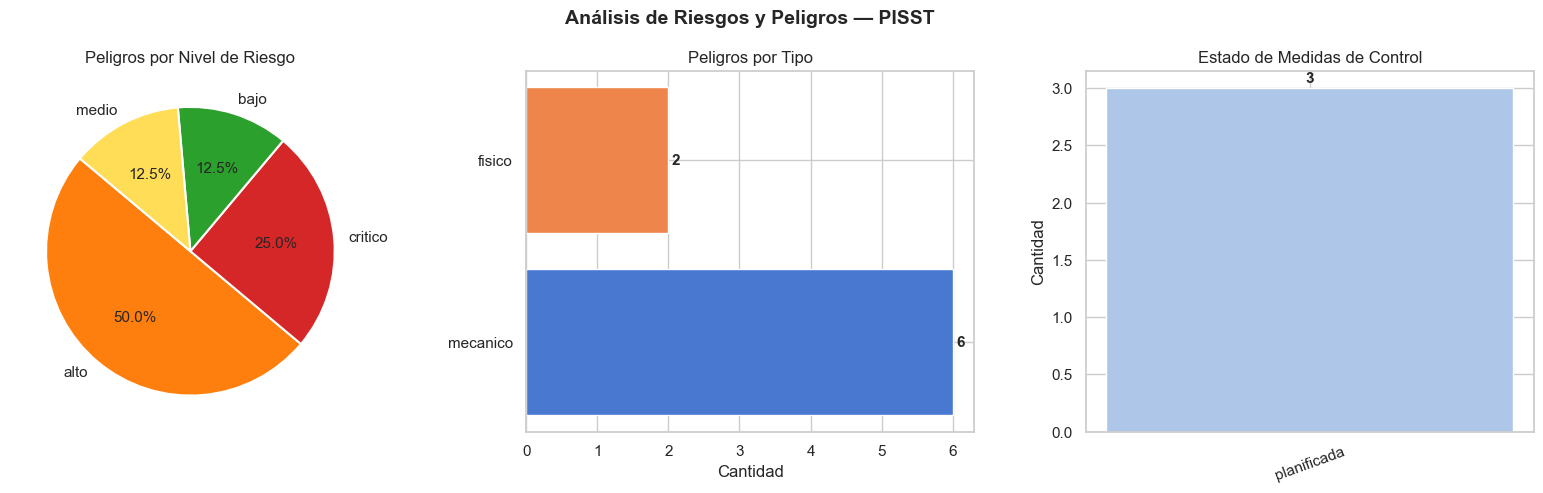

Gráfica guardada en data/processed/riesgos_graficas.png


In [6]:
if len(df_peligros) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Análisis de Riesgos y Peligros — PISST', fontsize=14, fontweight='bold')

    # --- Gráfica 1: Torta de niveles de riesgo ---
    nivel_counts = df_peligros['nivel_riesgo'].value_counts()
    colores_nivel = {
        'critico': '#d62728', 'alto': '#ff7f0e',
        'medio': '#ffdd57',   'bajo': '#2ca02c', 'sin_evaluar': '#aec7e8'
    }
    colores = [colores_nivel.get(n, '#999') for n in nivel_counts.index]
    axes[0].pie(
        nivel_counts.values,
        labels=nivel_counts.index,
        colors=colores,
        autopct='%1.1f%%',
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    axes[0].set_title('Peligros por Nivel de Riesgo')

    # --- Gráfica 2: Tipos de peligro ---
    tipo_counts = df_peligros['tipo_peligro'].value_counts()
    bars = axes[1].barh(tipo_counts.index, tipo_counts.values,
                        color=sns.color_palette("muted", len(tipo_counts)))
    axes[1].set_title('Peligros por Tipo')
    axes[1].set_xlabel('Cantidad')
    for bar, val in zip(bars, tipo_counts.values):
        axes[1].text(val + 0.05, bar.get_y() + bar.get_height() / 2,
                     str(val), va='center', fontweight='bold')

    # --- Gráfica 3: Estado de medidas de control ---
    if len(df_controles) > 0:
        estado_counts = df_controles['estado'].value_counts()
        colores_estado = {'implementada': '#2ca02c', 'completada': '#2ca02c',
                          'en_ejecucion': '#ffdd57', 'planificada': '#aec7e8'}
        c = [colores_estado.get(e, '#999') for e in estado_counts.index]
        axes[2].bar(estado_counts.index, estado_counts.values, color=c, edgecolor='white')
        axes[2].set_title('Estado de Medidas de Control')
        axes[2].set_ylabel('Cantidad')
        axes[2].tick_params(axis='x', rotation=20)
        for i, v in enumerate(estado_counts.values):
            axes[2].text(i, v + 0.05, str(v), ha='center', fontweight='bold')
    else:
        axes[2].text(0.5, 0.5, 'Sin medidas\nregistradas',
                     ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
        axes[2].set_title('Estado de Medidas de Control')

    plt.tight_layout()
    os.makedirs('../data/processed', exist_ok=True)
    plt.savefig('../data/processed/riesgos_graficas.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Gráfica guardada en data/processed/riesgos_graficas.png')
else:
    print('Sin datos para graficar.')

## 6. Transformaciones y cálculos (lógica del servicio)

In [7]:
if len(df_peligros) == 0:
    print('Sin datos — el servicio retornaría ceros.')
else:
    total_peligros = len(df_peligros)

    # Distribución por nivel de riesgo
    distribucion_nivel = df_peligros['nivel_riesgo'].value_counts().to_dict()

    # % con medidas de control implementadas (estado = 'implementada')
    peligros_con_control = df_controles[df_controles['estado'] == 'implementada']['peligro_id'].nunique()
    pct_con_control = round(peligros_con_control / total_peligros * 100, 1) if total_peligros > 0 else 0.0

    # Peligros críticos sin ninguna medida de control
    peligros_ids_con_control = set(df_controles['peligro_id'].tolist())
    df_criticos = df_peligros[df_peligros['nivel_riesgo'] == 'critico']
    criticos_sin_control = len(df_criticos[~df_criticos['peligro_id'].astype(str).isin(peligros_ids_con_control)])

    # Distribución por tipo de peligro
    distribucion_tipo = df_peligros['tipo_peligro'].value_counts().to_dict()

    resultado = {
        'total_peligros': total_peligros,
        'por_nivel': distribucion_nivel,
        'por_tipo': distribucion_tipo,
        'pct_con_control_implementado': pct_con_control,
        'criticos_sin_control': criticos_sin_control,
    }

    import json
    print(json.dumps(resultado, indent=2, ensure_ascii=False))

{
  "total_peligros": 8,
  "por_nivel": {
    "alto": 4,
    "critico": 2,
    "bajo": 1,
    "medio": 1
  },
  "por_tipo": {
    "mecanico": 6,
    "fisico": 2
  },
  "pct_con_control_implementado": 0.0,
  "criticos_sin_control": 2
}


## 7. Exportación de hallazgos

In [8]:
os.makedirs('../data/processed', exist_ok=True)

if len(df_peligros) > 0:
    df_peligros.to_csv('../data/processed/riesgos_explorados.csv', index=False)
    df_controles.to_csv('../data/processed/controles_explorados.csv', index=False)
    print('Exportado a data/processed/')

Exportado a data/processed/


## 8. Conclusiones para el servicio

- `analizar_riesgos()` necesita dos queries: una para peligros+evaluaciones, otra para controles
- El % de control se calcula sobre `medidas_control.estado == 'implementada'` (no solo existir la medida)
- Los peligros críticos sin ninguna medida son la alerta más importante para SST
- Multi-tenancy: ambas queries filtran por `empresa_id`